# Customer Churn Prediction using Machine Learning

This project predicts whether a telecom customer is likely to leave the company using customer demographic, service, contract, and billing data.

## 1. Import Libraries

In this step, required Python libraries are imported for data analysis, visualization, machine learning, and model evaluation.

In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## 2. Load Dataset

The Telco Customer Churn dataset is loaded using Pandas. Each row represents one customer, and the target column is `Churn`.

In [37]:
df = pd.read_csv('/Users/vikirthan17/Documents/customer_churn_prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Dataset Overview

The dataset shape, data types, missing values, and churn distribution are checked to understand the structure of the dataset.

In [38]:
df.shape

(7043, 21)

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [40]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [41]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [42]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [43]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## 4. Data Cleaning

The `TotalCharges` column is converted into numeric format because it should represent numerical payment values. Missing values are filled using the median value. The `customerID` column is removed because it is only an identifier and does not help in prediction.

In [44]:
df['TotalCharges'].dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [45]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [46]:
df.drop('customerID', axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5. Exploratory Data Analysis

EDA is performed to understand how different customer features are related to churn.

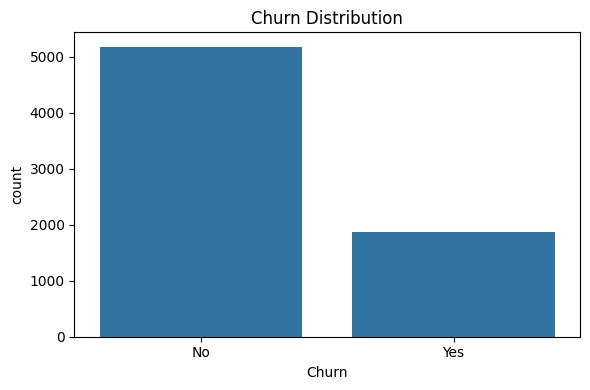

In [47]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.tight_layout()
plt.show()

### Insight: Churn Distribution

Most customers did not churn, but a noticeable number of customers left the company. This shows why churn prediction is important for customer retention.

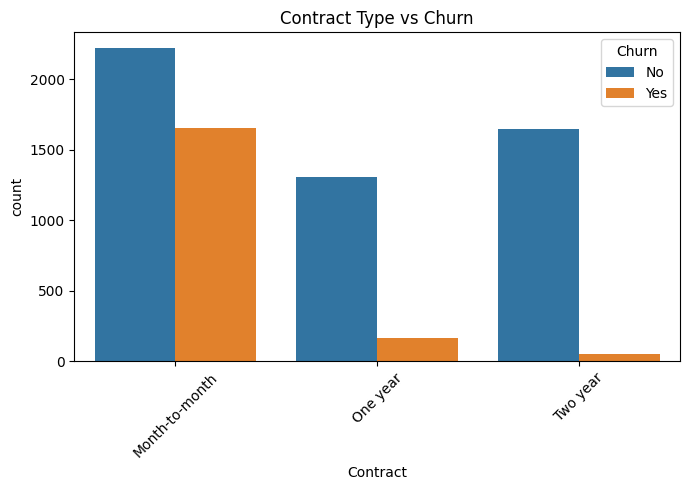

In [48]:
plt.figure(figsize=(7,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight: Contract Type vs Churn

Customers with month-to-month contracts have a higher churn rate compared to one-year and two-year contract customers.

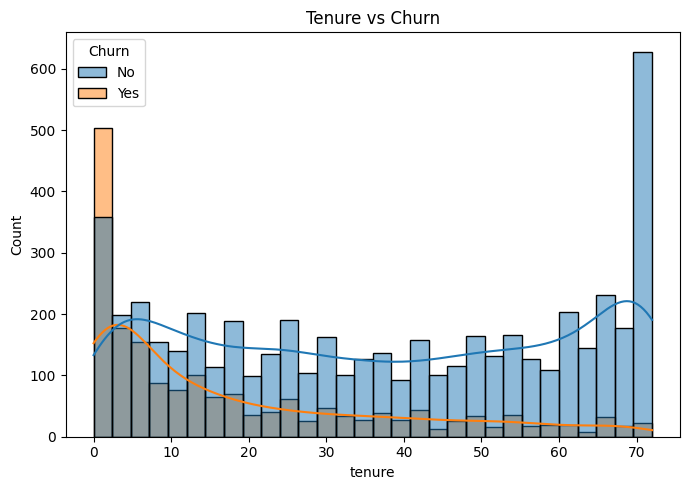

In [49]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure vs Churn")
plt.tight_layout()
plt.show()

### Insight: Tenure vs Churn

Customers with low tenure are more likely to churn. This shows that new customers are at higher risk of leaving.

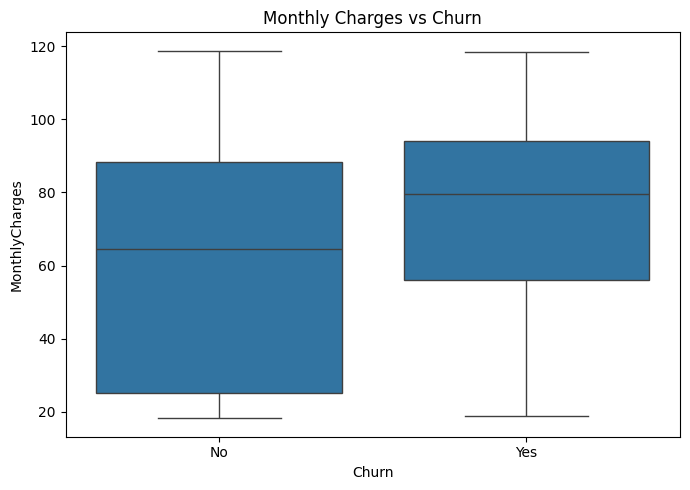

In [50]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.show()

### Insight: Monthly Charges vs Churn

Customers who churn usually have higher monthly charges. This suggests that expensive monthly bills may influence customer churn.

In [51]:
df.isnull().sum()
df['Churn'].value_counts()
df['TotalCharges'].dtype

dtype('float64')

In [52]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [53]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 6. Data Encoding

Categorical columns are converted into numeric values using Label Encoding because machine learning models cannot directly understand text values.

In [54]:
categorical_cols= df.select_dtypes(include=['object']).columns
categorical_cols

/var/folders/yj/2f9160pn1fs77dbpk31jb5b80000gn/T/ipykernel_12122/3738670384.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols= df.select_dtypes(include=['object']).columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [55]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for column in categorical_cols:
    df[column]= le.fit_transform(df[column])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [56]:
df['Churn'].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## 7. Feature and Target Split

The dataset is split into input features `X` and target variable `y`. The target variable is `Churn`.

In [57]:
x=df.drop('Churn', axis=1)
y=df['Churn']

## 8. Train-Test Split

The dataset is divided into training and testing sets. 80% of the data is used for training, and 20% is used for testing.

In [58]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)
print("X_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
x_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


## 9. Model Training

Multiple machine learning models are trained and compared, including Logistic Regression, Scaled Logistic Regression, Balanced Logistic Regression, and Random Forest.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model= LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

y_pred_log= log_model.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8147622427253371
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_model= RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf= rf_model.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7977288857345636
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



## 10. Feature Scaling

StandardScaler is used to scale the input features. Scaling helps Logistic Regression train better because features have different value ranges.

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [62]:
log_model_scaled= LogisticRegression(max_iter=2000)
log_model_scaled.fit(x_train_scaled, y_train)
 
y_pred_log_scaled= log_model_scaled.predict(x_test_scaled)

print("Scaled Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_scaled))
print(classification_report(y_test, y_pred_log_scaled))

Scaled Logistic Regression Accuracy: 0.815471965933286
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



## 11. Balanced Logistic Regression

The dataset has more non-churn customers than churn customers. Balanced Logistic Regression is used to give more importance to the minority churn class.

In [63]:
log_model_balanced= LogisticRegression(max_iter=2000, class_weight='balanced')
log_model_balanced.fit(x_train_scaled, y_train)

y_pred_log_balanced= log_model_balanced.predict(x_test_scaled)

print("Balanced Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_balanced))
print(classification_report(y_test, y_pred_log_balanced))

Balanced Logistic Regression Accuracy: 0.7565649396735273
              precision    recall  f1-score   support

           0       0.93      0.73      0.81      1036
           1       0.53      0.84      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



## 12. Model Comparison

The models are compared using accuracy, churn recall, and churn F1-score. For this project, churn recall is very important because the main goal is to identify customers who are likely to leave.

In [64]:
model_results= pd.DataFrame({
    'Model': ['Logistic Regression', 'Scaled Logistic Regression', 'Balanced Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_log_scaled), accuracy_score(y_test, y_pred_log_balanced), accuracy_score(y_test, y_pred_rf)],

    'Churn Recall': [ 0.57, 0.58, 0.84, 0.47 ],
    'Churn F1-score': [0.62, 0.62, 0.65, 0.55]
})
model_results

,Model,Accuracy,Churn Recall,Churn F1-score
0,Logistic Regression,0.814762,0.57,0.62
1,Scaled Logistic Regression,0.815472,0.58,0.62
2,Balanced Logistic Regression,0.756565,0.84,0.65
3,Random Forest,0.797729,0.47,0.55


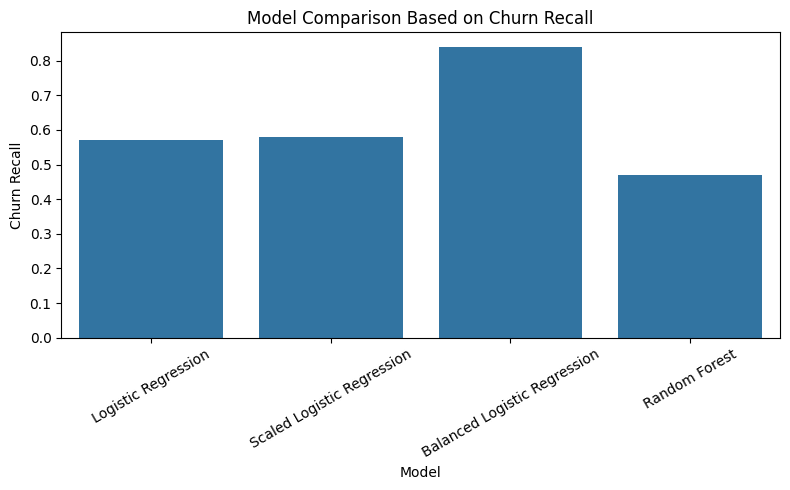

In [65]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Churn Recall', data=model_results)
plt.title("Model Comparison Based on Churn Recall")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/Users/vikirthan17/Documents/customer_churn_prediction/images/churn_recall_comparison.png")
plt.show()

## 13. Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified by the final model.

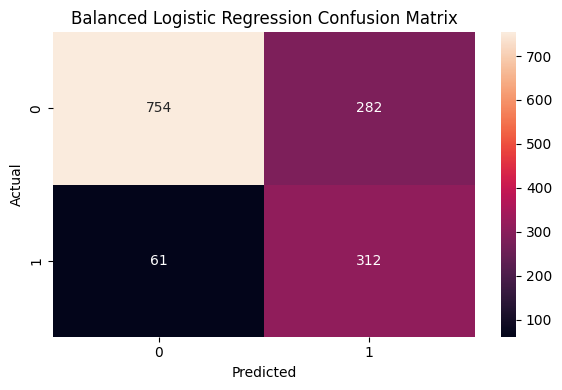

In [66]:
cm_balanced= confusion_matrix(y_test, y_pred_log_balanced)

plt.figure(figsize=(6,4))
sns.heatmap(cm_balanced, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("/Users/vikirthan17/Documents/customer_churn_prediction/images/confusion_matrix_balanced_logistic.png")
plt.show()

## 14. Important Features

The most important features for churn prediction are identified using the absolute coefficient values from the Balanced Logistic Regression model.

In [67]:
coefficients= pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': log_model_balanced.coef_[0]
})

coefficients['Absolute_Coefficient']= coefficients['Coefficient'].abs()
coefficients= coefficients.sort_values(by='Absolute_Coefficient', ascending=False)
coefficients

,Feature,Coefficient,Absolute_Coefficient
4,tenure,-1.194596,1.194596
17,MonthlyCharges,0.670532,0.670532
14,Contract,-0.641695,0.641695
18,TotalCharges,0.550339,0.550339
5,PhoneService,-0.295086,0.295086
8,OnlineSecurity,-0.244755,0.244755
11,TechSupport,-0.209618,0.209618
15,PaperlessBilling,0.167503,0.167503
7,InternetService,0.155614,0.155614
9,OnlineBackup,-0.133017,0.133017


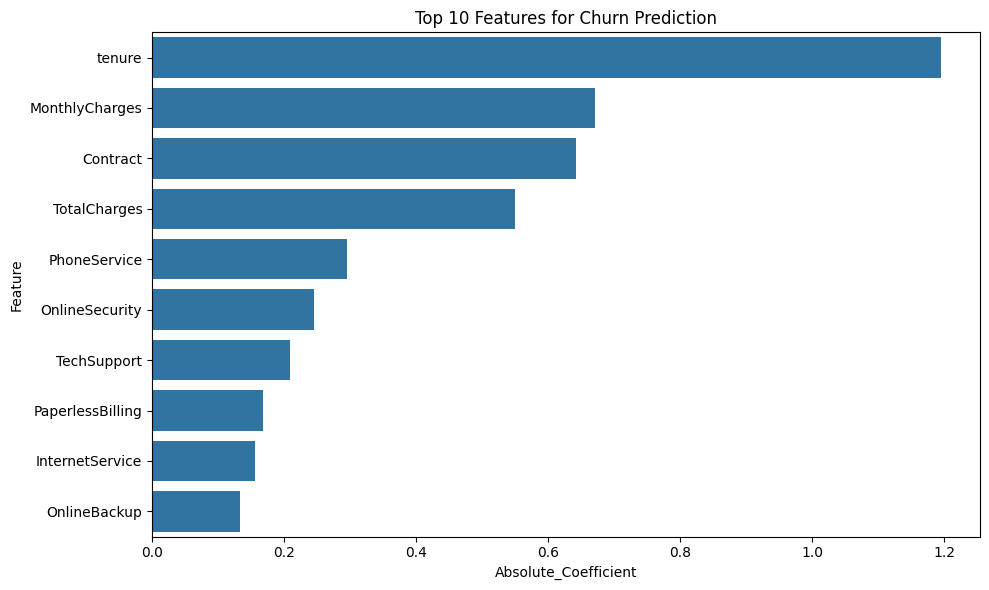

In [68]:
top_features= coefficients.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=top_features)
plt.title("Top 10 Features for Churn Prediction")
plt.tight_layout()
plt.savefig("/Users/vikirthan17/Documents/customer_churn_prediction/images/top_features.png")
plt.show()

## 15. Final Model Selection

Balanced Logistic Regression is selected as the final model because it achieved the highest churn recall. This means it can identify more customers who are likely to churn.

## 16. Save Final Model

The final trained model and scaler are saved using Joblib so they can be reused later without retraining.

In [69]:
import joblib
joblib.dump(log_model_balanced, '/Users/vikirthan17/Documents/customer_churn_prediction/models/logistic_regression_balanced.pkl')
joblib.dump(scaler, '/Users/vikirthan17/Documents/customer_churn_prediction/models/scaler.pkl')

['/Users/vikirthan17/Documents/customer_churn_prediction/models/scaler.pkl']

In [70]:
import os
print(os.path.exists('/Users/vikirthan17/Documents/customer_churn_prediction/models/logistic_regression_balanced.pkl'))
print(os.path.exists('/Users/vikirthan17/Documents/customer_churn_prediction/models/scaler.pkl'))

True
True
